<center><span style="font-size:50px;"><b>INITIAL ANALYSIS</b></span></center>

In [55]:
import requests
import pandas as pd
from io import StringIO
import time
import os
import geopandas as gpd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

---

---

---

<center><span style="font-size:30px;"><b>UPLOADING DATA</b></span></center>

In [3]:
df_raw = pd.read_csv("data/INGV/ingv_raw_earthquakes_1985_2025_complete.csv")

In [4]:
print(f"The uploaded dataframe has {len(df_raw):_} rows and {len(df_raw.columns):_} columns.")
memory = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")
print(df_raw.columns)
display( pd.concat([df_raw.head(5),df_raw.tail(5)]) )

The uploaded dataframe has 216_097 rows and 14 columns.
It occupies 89.80 MB in RAM memory
Index(['#eventid', 'time', 'latitude', 'longitude', 'depth/km', 'author',
       'catalog', 'contributor', 'contributorid', 'magtype', 'magnitude',
       'magauthor', 'eventlocationname', 'eventtype'],
      dtype='str')


,#eventid,time,latitude,longitude,depth/km,author,catalog,contributor,contributorid,magtype,magnitude,magauthor,eventlocationname,eventtype
0,2289,1985-01-28T08:45:53.200000,42.5150,13.3130,10.0,BULLETIN-VAX,NaN,NaN,NaN,Md,2.5,--,1 km SE Capitignano (AQ),earthquake
1,2249,1985-01-27T03:24:43.880000,40.7590,15.2500,10.0,BULLETIN-VAX,NaN,NaN,NaN,Md,2.9,--,3 km NW Valva (SA),earthquake
2,2159,1985-01-25T23:33:12.210000,39.1350,16.0000,99.7,BULLETIN-VAX,NaN,NaN,NaN,Md,3.1,--,Costa Calabra nord-occidentale (Cosenza),earthquake
3,2149,1985-01-25T22:26:11.110000,40.5710,19.3100,10.0,BULLETIN-VAX,NaN,NaN,NaN,Md,2.8,--,Costa Albanese settentrionale (ALBANIA),earthquake
4,2089,1985-01-23T16:11:34.960000,38.1700,20.6190,10.0,BULLETIN-VAX,NaN,NaN,NaN,M,4.3,--,Costa Greca Ionica (GRECIA),earthquake
216092,44752202,2025-12-01T10:35:34.450000,45.8927,11.9652,7.8,SURVEY-INGV,NaN,NaN,NaN,ML,1.5,--,3 km W Valdobbiadene (TV),earthquake
216093,44751392,2025-12-01T07:12:13.000000,42.7787,12.7258,10.4,SURVEY-INGV,NaN,NaN,NaN,ML,1.9,--,5 km N Spoleto (PG),earthquake
216094,44750742,2025-12-01T03:10:19.730000,45.8738,7.0510,11.1,SURVEY-INGV,NaN,NaN,NaN,ML,1.6,--,11 km NE Courmayeur (AO),earthquake
216095,44750662,2025-12-01T02:25:48.990000,44.1677,9.9072,6.4,SURVEY-INGV,NaN,NaN,NaN,ML,1.7,--,1 km NW Santo Stefano di Magra (SP),earthquake
216096,44750592,2025-12-01T01:27:50.160000,44.5130,10.2288,25.0,SURVEY-INGV,NaN,NaN,NaN,ML,2.4,--,2 km E Tizzano Val Parma (PR),earthquake


Meaning of the columns:
* **`#eventid`**: A unique numerical identifier for the specific seismic event in the database (e.g., `2289`).
* **`time`**: The precise date and time the earthquake occurred, usually in UTC. It follows the ISO 8601 format (YYYY-MM-DDTHH:MM:SS).
* **`latitude`**: The geographic coordinate specifying the north-south position.
* **`longitude`**: The geographic coordinate specifying the east-west position.
* **`depth/km`**: The hypocenter depth, measured in kilometers below the earth's surface.
* **`author`**: The organization or system that performed the initial calculation or analysis.
* **`catalog`**: The specific seismic catalog or database from which this record originates.
* **`contributor`**: The agency or institution that provided the data for this event.
* **`contributorid`**: The specific ID assigned to the event by the contributing agency.
* **`magtype`**: The scale used to measure the magnitude (see below).
* **`magnitude`**: The numerical value of the earthquake's energy release.
* **`magauthor`**: The agency responsible for calculating the magnitude value.
* **`eventlocationname`**: A human-readable description of the epicenter's location (e.g., `1 km SE Capitignano`).
* **`eventtype`**: The nature of the event, distinguishing between natural "earthquakes" and man-made events like explosions.


#### MAGTYPE meaning
In seismology, different *magnitude types* are used because a single scale cannot accurately measure every earthquake. Depending on the distance from the sensor, the depth, and the strength of the earthquake, scientists choose the most appropriate calculation method.

Here is what each `magtype` in your dataset refers to:
* **ML (Local Magnitude):** Commonly known as the **Richter Scale**. It is calculated based on the maximum amplitude of seismic waves recorded on a specific type of seismograph. It is very accurate for local earthquakes (within 600 km) but "saturates" for very large events (above magnitude 7.0), meaning it fails to reflect the true size of massive quakes.
* **Md (Duration Magnitude):** Calculated based on the **duration** (length) of the seismic signal coda (the "tail" of the wave). This is often used for smaller earthquakes where the signal is too weak to get a clear amplitude reading but persists long enough to measure.
* **M (Magnitude - Undefined):** This is a generic label used when the specific scale is not documented or is a weighted average of several types. It simply indicates that a magnitude was recorded without specifying the method. (DA CERCARE SUL SITO INGV)
* **Mw (Moment Magnitude):** The most modern and reliable scale for large earthquakes. It measures the "Seismic Moment," which is related to the physical size of the fault rupture and the energy released. Unlike Richter (ML), it does not saturate and is used by agencies like the USGS for most significant global events.
* **mb (Body-wave Magnitude):** Calculated using the first arrival of P-waves (primary waves) that travel through the interior of the Earth. It is particularly useful for measuring deep earthquakes or events occurring at great distances (teleseismic distances).
* **Mwp (P-wave Moment Magnitude):** A specialized, rapid version of the Moment Magnitude calculated specifically from the very first P-wave arrival. It is often used by tsunami warning centers because it allows for a very quick estimation of the earthquake's size before slower waves have even arrived.

---

---

---

<center><span style="font-size:30px;"><b>CHECKING DATA</b></span></center>

### MAGTYPE

In [71]:
df_raw['magtype'].value_counts()

magtype
ML     158763
Md      52968
M        3283
Mw        885
mb        184
Mwp        14
Name: count, dtype: int64

Majority are ML and Md.

### DEPTH

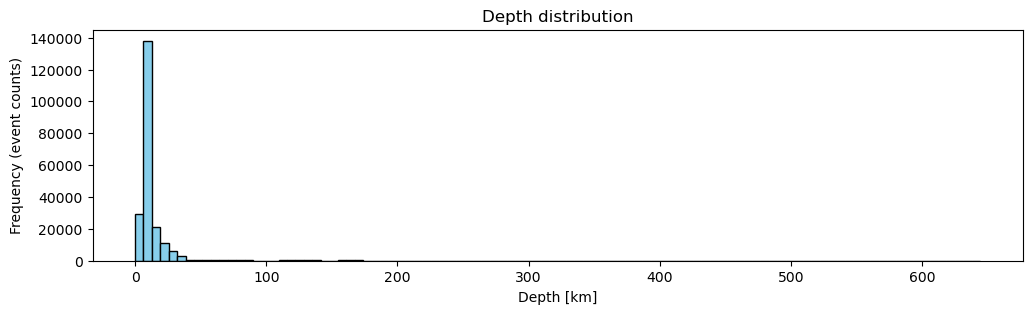

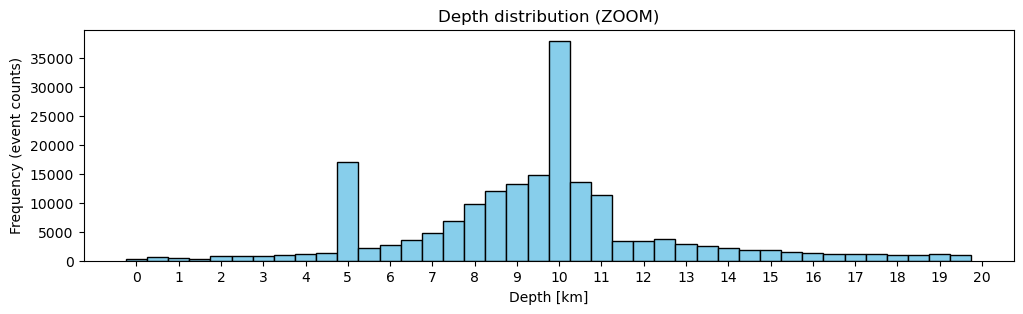

In [86]:
data = df_raw['depth/km'].dropna()

plt.figure(figsize=(12,3))
plt.hist(data, bins=100, edgecolor='black', color='skyblue')
plt.xlabel('Depth [km]')
plt.ylabel('Frequency (event counts)')
plt.title('Depth distribution')
plt.show()

plt.figure(figsize=(12,3))
max_val = 20
bins = np.arange( -0.25, max_val + 0.25, 0.5)
plt.hist(data, bins=bins, range=(0,max_val), edgecolor='black', color='skyblue')

plt.xticks(np.arange(0, max_val + 0.5, 1))

plt.xlabel('Depth [km]')
plt.ylabel('Frequency (event counts)')
plt.title('Depth distribution (ZOOM)')
plt.show()

### MAGNITUDE

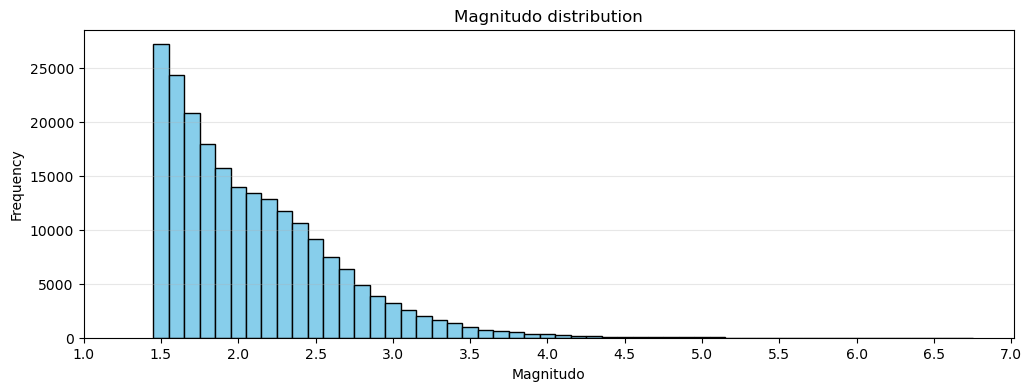

In [66]:
data = df_raw['magnitude'].dropna()

# 1. Configurazione Bin (ampiezza 0.1 come richiesto prima)
bins = np.arange(data.min()-0.05, data.max() + 0.05, 0.1)

# 2. Creazione del grafico
plt.figure(figsize=(12,4))
plt.hist(data, bins=bins, edgecolor='black', color='skyblue')

# 3. Impostazione dei ticks ogni 0.5
# Usiamo floor e ceil per assicurarci che la scala copra tutto l'intervallo
tick_min = np.floor(data.min())
tick_max = np.ceil(data.max())
plt.xticks(np.arange(tick_min, tick_max + 0.5, 0.5))

# 4. Etichette e stile
plt.xlabel('Magnitudo')
plt.ylabel('Frequency')
plt.title('Magnitudo distribution')
plt.grid(axis='y', alpha=0.3) # Aggiunge una griglia leggera per la leggibilità

### AUTHOR

In [87]:
df_raw['author'].value_counts()

author
BULLETIN-INGV                            84722
BULLETIN-VAX                             51141
BULLETIN-SISPICK                         40030
SURVEY-INGV                              36012
REMO-INGV                                 1973
BULLETIN-OV                                498
SURVEY-INGV-CT                             430
SURVEY-INGV-CT#SeismPicker_SO-OE           404
CSEM                                       262
SURVEY-INGV-OV#WESSEL                      179
SURVEY-INGV-A                              109
SURVEY-INGV-CT#KATALOC                     100
SURVEY-INGV-OV#SiSmi                        92
SURVEY-INGV-OV                              40
AGENDA-INGV                                 38
SURVEY-INGV-CSEM                            30
SURVEY-INGV-OV#WinPick                      17
SURVEY-INGV-CT#SeismPicker_Analyst-OE       11
BULLETIN-INGV-A                              3
SURVEY-INGV-GEOFON                           2
SED                                          1
THE   

Il 98% dei dati proviene da 4 fonti (BULLETIN-INGV, BULLETIN-VAX, BULLETIN-SISPICK, SURVEY-INGV).

---

---

---